# Access SWOT L2 Oceanography Data in AWS Cloud - Smoothed Data (2 km)

#### Code from https://podaac.github.io/tutorials/notebooks/datasets/DirectCloud_Access_SWOT_Oceanography.html

And modified code from S Fournier

In [106]:
import time
import xarray as xr
import numpy as np
import pandas as pd
import s3fs
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
import cartopy
import cartopy.feature as cfeature
import earthaccess
from earthaccess import Auth, DataCollections, DataGranules, Store
%matplotlib inline

In [2]:
auth = earthaccess.login()

## Access SWOT Level 2 KaRIn Low Rate Sea Surface Height Data Product Files on cloud

Set lat/lon bounds of data

In [68]:
lonmin = -58
lonmax = -40
latmin = 50
latmax = 65

Earlier version of SWOT data - Version C (2.0)

In [69]:
#retrieves granule from the days we want
#Version C (2.0): old version

#Basic: 2km
#Unsmoothed: 250m but separated between left and right swath (2 groups)
#Expert: just contains many many variables

#karin_results = earthaccess.search_data(short_name = 'SWOT_L2_LR_SSH_2.0',temporal = ("2024-10-01", "2024-10-11"),
    #bounding_box = (lonmin,latmin,lonmax,latmax),
    #granule_name = '*Basic*')

Note: THe bounding box filters which granules are returned, i.e. it only returns files that intersect that bounding box, but the data within each granule may still extend outside it

In [132]:
#retrieves granule from the day we want
#Version D: new version

#Basic: 2km
#Unsmoothed: 250m but separated between left and right swath (2 groups)
#Expert: just contains many many variables

karin_results_basic = earthaccess.search_data(short_name = 'SWOT_L2_LR_SSH_D',
                                              temporal = ("2024-06-01", "2024-06-11"),
                                              bounding_box = (lonmin,latmin,lonmax,latmax),
                                              granule_name = '*Basic*')

In [133]:
#opens granules and load into xarray dataset
ds_basic = xr.open_mfdataset(earthaccess.open(karin_results_basic), combine='nested', concat_dim="num_lines", decode_times=True, engine='h5netcdf')
ds_basic

QUEUEING TASKS | :   0%|          | 0/27 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/27 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/27 [00:00<?, ?it/s]

<xarray.Dataset> Size: 3GB
Dimensions:                                (num_lines: 266382, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    longitude                              (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 2MB dask.array<chunksize=(9866,), meta=np.ndarray>
    time_tai                               (num_lines) datetime64[ns] 2MB dask.array<chunksize=(9866,), meta=np.ndarray>
    ssh_karin                              (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ssh_karin_qual                         (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ssh_karin_uncert                       (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ssha_karin                             (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    geoid                                  (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    internal_tide_hret                     (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    height_cor_xover                       (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    height_cor_xover_qual                  (num_lines, num_pixels) float32 74MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2025-10-25T22:08:18Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.79268792501122
    ssha_variance:                                 0.4727157819911392
    references:                                    V1.4.1
    equator_longitude:                             -59.01

## Cross Over Calibration and Corrections

In [134]:
ds_basic['ssha_karin_2_corrected'] = ds_basic.ssha_karin_2 + ds_basic.height_cor_xover
ds_basic.ssha_karin_2_corrected

<xarray.DataArray 'ssha_karin_2_corrected' (num_lines: 266382, num_pixels: 69)> Size: 147MB
dask.array<add, shape=(266382, 69), dtype=float64, chunksize=(9866, 69), chunktype=numpy.ndarray>
Coordinates:
    latitude   (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    longitude  (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels

In [135]:
ds_basic.ssha_karin_2_qual

<xarray.DataArray 'ssha_karin_2_qual' (num_lines: 266382, num_pixels: 69)> Size: 147MB
dask.array<concatenate, shape=(266382, 69), dtype=float64, chunksize=(9866, 69), chunktype=numpy.ndarray>
Coordinates:
    latitude   (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    longitude  (num_lines, num_pixels) float64 147MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Attributes:
    long_name:      sea surface height anomaly quality flag
    standard_name:  status_flag
    flag_meanings:  suspect_large_ssh_delta suspect_large_ssh_std suspect_lar...
    flag_masks:     [         1          2          4          8         16  ...
    valid_min:      0
    valid_max:      3876569055
    comment:        Quality flag for the SSHA from KaRIn in the ssha_karin_2 ...

In [136]:
ds_basic.ssha_karin_2_qual.flag_masks

array([         1,          2,          4,          8,         16,
               64,        128,        256,        512,       1024,
             2048,       4096,       8192,      32768,      65536,
           131072,     262144,     524288,   16777216,   33554432,
         67108864,  536870912, 1073741824, 2147483648], dtype=uint32)

In [137]:
len(ds_basic.ssha_karin_2_qual.flag_masks)

24

In [138]:
len(flag_masks)

24

flag 512 is not included?

In [139]:
# without 512
# flag_masks = [1,2,4,8,16,64,128,256,1024,2048,4096,8192,32768,65536,131072,262144,524288,16777216,33554432,67108864,536870912,1073741824,2147483648]

# all flags removed
flag_masks = ds_basic.ssha_karin_2_qual.flag_masks

qual = ds_basic.ssha_karin_2_qual.astype("uint32")
bad_mask = xr.zeros_like(qual, dtype=bool)
for f in flag_masks:
    bad_mask = bad_mask | ((qual & np.uint32(f)) != 0)

good = (~bad_mask) & (ds_basic.rain_flag == 0)
ds_basic['ssha_karin_2_corrected'] = ds_basic.ssha_karin_2_corrected.where(good)

## Plot

In [140]:
ssha_corrected = ds_basic.ssha_karin_2_corrected

In [141]:
mask = (
    (ssha_corrected.latitude >= 40) & (ssha_corrected.latitude <= 80) &
    (ssha_corrected.longitude >= 300) & (ssha_corrected.longitude <= 320)
).compute()

ssha_greenland = ssha_corrected.where(mask, drop=True).load()

In [143]:
time_start

NaT

In [144]:
time_end

Timestamp('2024-06-11 18:39:53.489569152')

In [146]:
ds_basic.time.values

array([                          'NaT',                           'NaT',
                                 'NaT', ...,
       '2024-06-11T18:39:52.860705792', '2024-06-11T18:39:53.175115392',
       '2024-06-11T18:39:53.489569152'], dtype='datetime64[ns]')

In [147]:
time_vals = pd.to_datetime(ds_basic.time.values)
time_vals = time_vals[~pd.isnull(time_vals)]
time_start = time_vals[0]
time_end = time_vals[-1]
title_time = f"{time_start.strftime('%m-%d-%Y')} to {time_end.strftime('%m-%d-%Y')}"

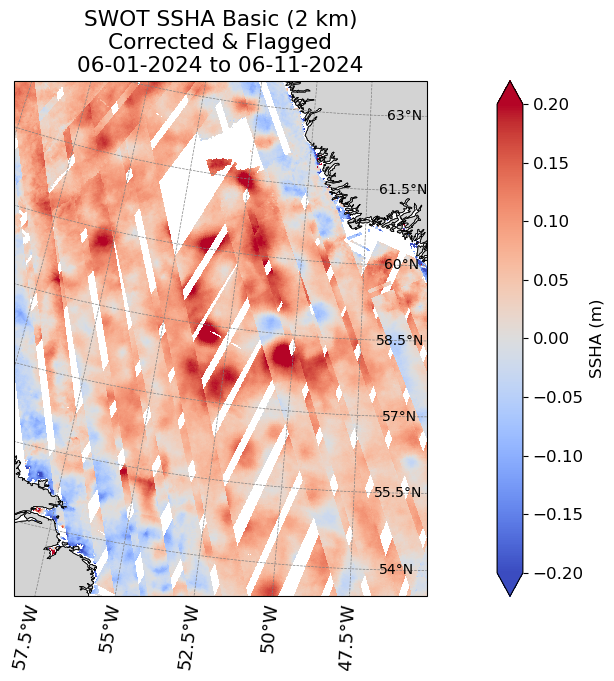

In [151]:
plt.rcParams['font.size'] = 13

fig = plt.figure(figsize=(10, 7))
map_proj = ccrs.NorthPolarStereo(central_longitude=-45)
ax = fig.add_subplot(1, 1, 1, projection=map_proj)

ax.set_extent([-58.5, -45, 53.5, 63], crs=ccrs.PlateCarree())
# ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

for feature, kwargs in [
    ('land', dict(facecolor='lightgray', edgecolor='black')),
    ('coastline', dict(facecolor='none', edgecolor='black')),
]:
    ax.add_feature(cfeature.NaturalEarthFeature('physical', feature, '10m', **kwargs), linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True
gl.ylabel_style = {'size': 10, 'rotation': 0}  # keeps lat labels upright on outside

pp = ssha_corrected.plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(), x="longitude", y="latitude",
    vmin=-0.2, vmax=0.2, cmap="coolwarm", add_colorbar=False,
)

cbar = plt.colorbar(pp, ax=ax, orientation="vertical", extend='both', fraction=0.03, pad=0.08)
cbar.set_label("SSHA (m)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

plt.title(f'SWOT SSHA Basic (2 km)\nCorrected & Flagged\n{title_time}')

plt.tight_layout()
plt.show()